In [1]:
%%bash
pip install mermaid-py > /dev/null

mkdir storm_mode
cd storm_mode
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_train_data.csv
wget -nc -q https://raw.githubusercontent.com/ahaberlie/unidata-workshop-2018/refs/heads/master/workshop/data/training/sample_test_data.csv

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


# Chapter 8.3 - Decision Trees

A [decision tree](https://en.wikipedia.org/wiki/Decision_tree_learning) is a supervised machine learning approach that generates a series of yes/no decisions based on sample features. Ultimately, it uses each learned decision to repeatedly split the samples into two subsets. A hierarchy of many split decisions can produce accurate predictions based on complex interrelationships between variables and labels.

A basic classification decision tree can be described with the following terms:

1. `split decision` - a rule that separates a dataset into two subsets. For example, testing to see if `rain >= 0.01` for a sample would split the dataset into `Yes (Rain)` and `No (No Rain)` subsets.
2. `Gini impurity` - a measure of how homogeneous sample labels are in a subset. The "goal" of the decision tree during each split decision is to make two subsets with homogenous labels.
3. `root node` - the first rule (split decision).
4. `decision nodes` - subsequent rules that result in further subset splitting.
5. `leaf nodes` - classification nodes where no further splits are performed. If the sample labels are not all the same, the most common label is used to classify samples that get to that node.

### Chapter 8.3.1 - Gini impurity

We can quantify the homogeneity of a set of sample labels by calculating the [Gini impurity](https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity). In the binary case, this equation is simplified to:

$$
G(p)=1-\big(p^2+(1-p)^2\big)=2p(1-p)
$$

Where $p$ is the fraction of samples in a node with a particular label (e.g., "Yes"), and $1 - p$ is fraction of samples that have the other label (e.g., "No").

There are some assumptions here:

1. The "observed" label frequencies in a node are assumed to be accurate estimates of the
   overall (true) label frequencies for the population of samples that may reach this node.

2. To generate a prediction for an "unobserved" sample, we imagine the following randomized rule:
   select one observed sample at random and use its label as the prediction.

If these assumptions are met, gini impurity measures how likely it is for a split decision to produce an incorrect prediction for a randomly selected sample. The probability comes from both the chance of choosing a sample with, for example, a label of "Yes" or "No" **and** the chance that you incorrectly predict "Yes" or "No" for that sample.

For a forecasting analogy, imagine grouping historical days by similar atmospheric ingredients. Within one such group, let $p$ be the historical fraction of rainy days. Gini impurity then quantifies how mixed the outcomes are in that ingredient regime: low Gini implies those ingredients almost always lead to the same outcome (high inherent predictability), while high Gini implies substantial overlap between rain and no-rain outcomes (lower inherent predictability).

**Examples**

If we have 10 samples in a subset and 5 of the samples have a 'Yes' label and 5 have a 'No' label, the calculation is solved as below:

**Example (binary labels):** 10 samples total, with 5 **Yes** and 5 **No**.

$$
p(\text{Yes})=\frac{5}{10}=0.5,\quad p(\text{No})=\frac{5}{10}=0.5
$$

**Gini impurity:**

$$
G = 1 - \left(p(\text{Yes})^2 + p(\text{No})^2\right)
  = 1 - \left(0.5^2 + 0.5^2\right)
  = 1 - (0.25 + 0.25)
  = 0.5
$$

As expected, the chance of an incorrect label in this subset is 50% ("coin flip" scenario). The probability of randomly picking a sample with a label of "Yes" is 0.5, and the probability of predicting that sample as a "No" is 0.5. If you remember [chained probabilities](https://en.wikipedia.org/wiki/Chain_rule_(probability)), the chance of both happening is 0.25. Similarly, the probability of picking a "No" sample label and predicting a "Yes" is 0.25. The additive probability is 0.5 (0.25 + 0.25), because these cases represent mutually exclusive situations where an incorrect prediction is made.

On the other hand, if we had another splitting choice that produced 8 'Yes' labels and 2 'No' labels, the calculation is solved as below:

**Example (binary labels):** 10 samples total, with 8 **Yes** and 2 **No**.

$$
p(\text{Yes})=\frac{8}{10}=0.8,\quad p(\text{No})=\frac{2}{10}=0.2
$$

**Gini impurity:**

$$
G = 1 - \left(p(\text{Yes})^2 + p(\text{No})^2\right)
  = 1 - \left(0.8^2 + 0.2^2\right)
  = 1 - (0.64 + 0.04)
  = 0.32
$$

This objectively produces a better split decision because the resulting labels are more homogenous. The probability of randomly picking a "Yes" sample label is 0.8, the chance of incorrectly predicting that label is 0.2, and the chance of both happening is 0.16. Similarly, randomly picking a "No" sample label is 0.2, the chance of incorrectly predicting that label is 0.8, and the chance of both happening is 0.16.

Finally, a perfect situation where there are 10 "Yes" sample labels and 0 "No" sample labels:

**Example (binary labels):** 10 samples total, with 10 **Yes** and 0 **No**.

$$
p(\text{Yes})=\frac{10}{10}=1.0,\quad p(\text{No})=\frac{0}{10}=0.0
$$

**Gini impurity:**

$$
G = 1 - \left(p(\text{Yes})^2 + p(\text{No})^2\right)
  = 1 - \left(1^2 + 0.0^2\right)
  = 1 - (1 + 0)
  = 0
$$

**Weighted split decisions**

The decision tree (specifically CART) calculates the gini impurity for each possible split decision. The final split decision encoded into the model is based on the decision that produces the smallest, weighted gini impurity for both sides of the split decision. Weighted impurity is based on the number of samples on each side of the split. For example, if you had a split decision that produced a subset of 2 samples, which both had "Yes" as a label, and a subset that had 10 samples, of which 5 had "Yes" and 5 had "No" as a label, the weighted Gini impurity would be calculated as:

**Split Subset #1**
$$
p(\text{Yes})=\frac{2}{2}=1.0,\quad p(\text{No})=\frac{0}{2}=0.0
$$

$$
G_1 = 1 - \left(p(\text{Yes})^2 + p(\text{No})^2\right)
  = 1 - \left(1^2 + 0.0^2\right)
  = 1 - (1 + 0)
  = 0
$$

**Split Subset #2**
$$
p(\text{Yes})=\frac{5}{10}=0.5,\quad p(\text{No})=\frac{5}{10}=0.5
$$

$$
G_2 = 1 - \left(p(\text{Yes})^2 + p(\text{No})^2\right)
  = 1 - \left(0.5^2 + 0.5^2\right)
  = 1 - (0.25 + 0.25)
  = 0.5
$$

**Weighted Gini impurity**
$$
G = \left(\frac{2}{12}\right)G_1 + \left(\frac{10}{12}\right)G_2
  = \left(\frac{2}{12}\right)(0) + \left(\frac{10}{12}\right)(0.5)
  = \frac{5}{12}
  \approx 0.4167
$$

*Your Turn*: Consider the two possible split decisions below. Calculate the weighted gini impurity for each case. Which one is the best choice?

In [2]:
from IPython.display import HTML, display
import base64, textwrap

# Your mermaid definitions
code1 = r"""
flowchart TB
  A["Root: CAPE > 500 ?"]
  A -- Yes --> B["4 Severe, 2 Not Severe Gini = ?"]
  A -- No  --> C["1 Severe, 3 Not Severe Gini = ?"]
"""

code2 = r"""
flowchart TB
  A["Root: shear > 40 ?"]
  A -- Yes --> B["4 Severe, 0 Not Severe Gini = ?"]
  A -- No  --> C["1 Severe, 5 Not Severe Gini = ?"]
"""

def mermaid_ink_img(mermaid_code: str) -> str:
    # mermaid.ink expects base64-url-safe of the diagram text
    b = base64.urlsafe_b64encode(mermaid_code.encode("utf-8")).decode("ascii")
    return f"https://mermaid.ink/img/{b}"

img1 = mermaid_ink_img(code1)
img2 = mermaid_ink_img(code2)

display(HTML(f"""
<div style="display:grid; grid-template-columns: 1fr 1fr; gap: 16px; align-items:start;">
  <div>
    <div style="font-weight:600; margin:0 0 6px 0;">Candidate Split A (CAPE)</div>
    <img src="{img1}" style="width:100%; border:1px solid #ddd; border-radius:8px; padding:8px;">
  </div>
  <div>
    <div style="font-weight:600; margin:0 0 6px 0;">Candidate Split B (Shear)</div>
    <img src="{img2}" style="width:100%; border:1px solid #ddd; border-radius:8px; padding:8px;">
  </div>
</div>
"""))

### Chapter 8.3.2 - Scikit-Learn `DecisionTreeClassifier`

As is the case with all supervised learning techniques, you are required to provide "expert" labels that are associated with each feature vector. Supervised learning techniques use a variety of ways to accurately model relationships between feature vectors and the given labels. As is described above, the decision tree attempts to create accurate predictions by applying a series of split decisions until samples are separated into homogeneous subsets. The idea is that similar cases will cascade down the decision tree nodes along similar paths, eventually ending up in the same final grouping. If the samples used to create (i.e., train) the decision tree are representative of the population, then unobserved/unlabeled samples should also follow these paths in the tree and be assigned accurate predictions.

Scikit-Learn has a decision tree model called [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier). This model uses the algorithm described above (or similar) to create split decision rules for the `root node` and `decision nodes`, so that sample subsets are ultimately organized into `leaf nodes` with homogeneous labels. Once in the `leaf node`, the classification decision is based on the most frequent label in that node.

The decision tree comes with useful default settings, but a few settings you may want to change/tweak are as follows:

- `max_depth`: This is the count of `decision nodes` + `leaf node` beyond the `root node`. A `max_depth` of 2 would produce a tree like this:

In [3]:
from mermaid import Mermaid

m = Mermaid(r"""
flowchart TB
  A["Root: shear > 40 ?"]
  A --Yes--> B["CAPE > 500 ?"]
  A --No-->  C["CAPE > 500 ?"]

  B --Yes--> D["Leaf: Severe (n=3)"]
  B --No-->  E["Leaf: Severe (n=2)"]

  C --Yes--> F["Leaf: Not Severe (n=1)"]
  C --No-->  G["Leaf: Not Severe (n=4)"]
""")

m

**Other parameters**

- `min_samples_split`: If `max_depth` is not set, the decision tree will continue to generate splitting rules as long as the subset passed to that node has at least this many samples. For example, if this is set to `2` (default), it will be converted to a `leaf node` if only one sample is available.

- `min_impurity_decrease`: A splitting decision will be made, as long as the resulting, weighted impurity is at least this much lower than the impurity in the original subset.

**Decision tree properties**

- `classes_`: the ordered labels in the tree.
- `feature_importances_`: the average decrease in impurity produced by split decsions for each feature. More important features are associated with a larger decrease in impurity on average.

### Chapter 8.3.3 - Training a decision tree

We will use the storm morphology dataset once again. However, we will simplify the predictions by converting them to:

```
0: not an MCS
1: an MCS
```

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_train = pd.read_csv("storm_mode/sample_train_data.csv")
df_test = pd.read_csv("storm_mode/sample_test_data.csv")

df_train = df_train.sort_values(by='datetime')
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_val = df_train[df_train['datetime'].dt.year >= 2012].copy()
df_train = df_train[df_train['datetime'].dt.year < 2012].copy()

df_train['MCS'] = df_train['label_name'] == 'MCS'
df_val['MCS'] = df_val['label_name'] == 'MCS'
df_test['MCS'] = df_test['label_name'] == 'MCS'

numeric_cols = df_train.select_dtypes(include="number").columns.tolist()
numeric_cols.remove('index')
numeric_cols.remove('label')
numeric_cols.remove('label1')

print("# training samples (lectures/homework/etc.) =", len(df_train))
print("# validation samples (practice exam) =", len(df_val))
print("# validation samples (actual exam) =", len(df_test))

# training samples (lectures/homework/etc.) = 350
# validation samples (practice exam) = 49
# validation samples (actual exam) = 100


The process of training the model is very similar to `KMeans`. We first need to transform the `pandas` data to numpy using only the numeric columns. You can print out the feature vectors (`x_train`, `x_val`, `x_test`) and labels (`y_train`, `y_val`, `y_test`) to examine their numpy representation.

In [5]:
x_train = df_train[numeric_cols].to_numpy()
y_train = df_train['MCS'].to_numpy()

x_val = df_val[numeric_cols].to_numpy()
y_val = df_val['MCS'].to_numpy()

x_test = df_test[numeric_cols].to_numpy()
y_test = df_test['MCS'].to_numpy()

print(x_train[:5], x_train.shape)
print(y_train[:5], y_train.shape)

[[2.57303251e+01 3.54756044e-01 3.10344420e+01 1.25215889e-02
  2.75163958e-02 3.36672000e+05 9.26400000e+03 5.50000000e+01
  5.61770924e+02 1.16000000e+02 9.13296219e-01 9.49024000e+05
  3.44549000e-04 1.37926950e+03 4.07295982e-01 3.39100000e+03
  2.63100000e+03 7.90000000e+02 3.47000000e+02]
 [2.45871148e+01 4.70851718e-01 2.07804957e+01 1.66898470e-02
  7.86187590e-03 3.65816000e+05 2.87600000e+03 5.00000000e+01
  4.54243000e+02 4.80000000e+01 9.56577615e-01 7.76924000e+05
  1.31213500e-04 1.55841409e+03 2.91477728e-01 3.43900000e+03
  2.58900000e+03 6.50000000e+02 3.04000000e+02]
 [3.07279886e+01 5.41432986e-01 5.99036549e+01 1.22664500e-01
  1.95169644e-01 7.56880000e+04 1.47720000e+04 6.00000000e+01
  2.23941478e+02 1.81200000e+03 9.18075124e-01 1.39792000e+05
  2.39403869e-02 5.64928958e+02 3.96406442e-01 2.64100000e+03
  2.32000000e+03 9.56000000e+02 7.82000000e+02]
 [3.10767281e+01 4.60555715e-01 6.94201830e+01 2.13526442e-01
  2.03975987e-01 2.95172000e+05 6.02080000e+04 6.5

Next, import the subclass from `sklearn.tree` and use `.fit` to train the CART classifier on the training data (`x_train` and `y_train`). We will use `max_depth=3` to help visualize the tree.

We can use `plot_tree` on the trained instance to examine its structure.

**Activity**

Get into groups of two. Interpret the graph below. What does each split decision mean? Can you confirm the `Gini impurity` scores for the `leaf nodes`? Can you calculate the following *training* data metrics and interpret what they mean? The basic decision tree should be *deterministic*, but check to make sure that this is true if you run it multiple times.

`True Positive or TP` - Count of correct `MCS` predictions. In other words, the count of actual `MCS` labels in a `leaf node` that has `MCS` as the prediction

`False Positive or FP` - Count of incorrect `MCS` predictions. In other words, the count of actual `Non-MCS` labels in a `leaf node` that has `MCS` as the prediction.

`False Negative or FN` - Count of how many actual `MCS` samples are incorrectly labeled as `Non-MCS`. In other words, the count of actual `MCS` samples in a `leaf node` that has `Non-MCS` as the prediction.

`True Negative or TN` - Count of how many actual `Non-MCS` samples are correctly labeled as `Non-MCS`. In other words, the count of actual `Non-MCS` samples in a `leaf node` that has `Non-MCS` as the prediction.

`Accuracy` = $\frac{TP + TN}{TP + FN + FP + TN}$

`Precision` = $\frac{TP}{TP + FP}$

`Recall` = $\frac{TP}{TP + FN}$

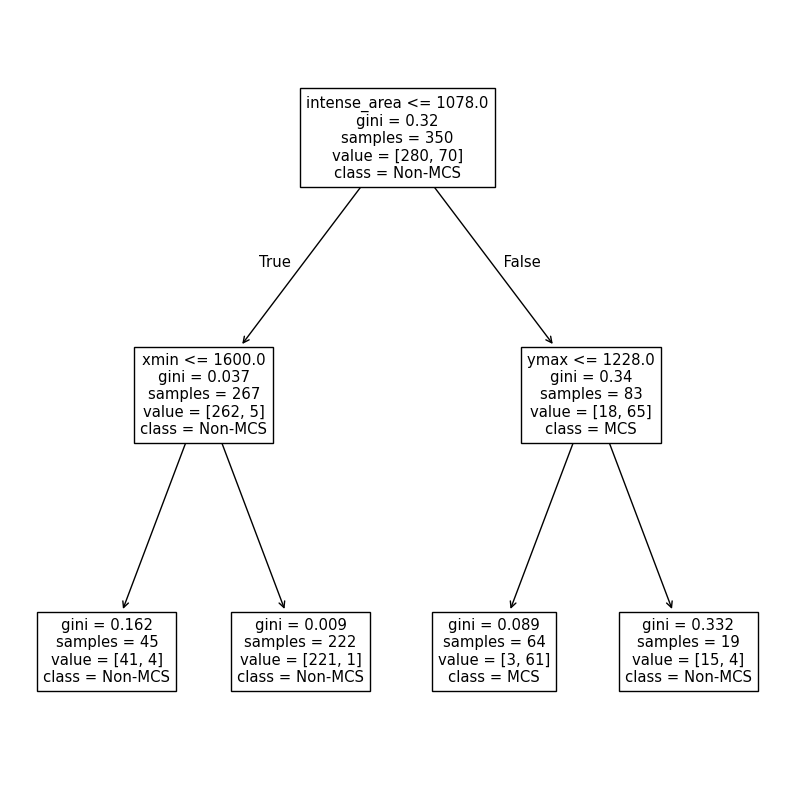

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 10, 10

from sklearn.tree import DecisionTreeClassifier, plot_tree

CART = DecisionTreeClassifier(max_depth=2).fit(X=x_train, y=y_train)

plot_tree(CART, feature_names=numeric_cols, class_names=['Non-MCS', 'MCS'])
plt.show()

We can create custom functions to calculate the metrics above. At some point, we wil use the built-in functions, but this is a useful exercise to understand how models are assessed.

The `DecisionTreeClassifier` method named `predict` takes a numpy array of feature vectors and assigns each vector a label (in this case, 0 for Non-MCS and 1 for MCS).

We have the "ground truth" in `y_train`, so we can directly compare all of the predictions with `y_train` to determine the performance of the model. We can perform a comparison to see if the value at each index in `y_train_predictions` and `y_train`. For example, if `y_train_predictions[0]` is `True` and `y_train[0]` is `True`, we know the feature vector at index 0 has a correct prediction. Additionally, since we know `True` and `False` are just special cases for `int` (True is 1, False is 0), we can find the sum of this comparison. This sum is equivalent to how many times the prediction is correct (TP + TN). If we divide this number by the total number of samples, we can get the `accuracy`.

**Activity**: Get into groups of 2. Using `numpy` only, calculate `TP`, `FP`, `FN`, and `TN`. Using these values, calculate `accuracy`, `precision`, and `recall`. Compare the results to the official `sklearn.metrics` methods--namely [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score), [precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score), and [recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html). Do they match up? Why might recall and precision be different from accuracy? What does that tell you about model performance on the `MCS` label? HINT: Think of what conditions must be true in both `y_train` and `y_train_predictions` for each case.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_train_predictions = CART.predict(x_train)
# y_train is the "ground truth"

# add your code here
TP = 1
FP = 1
FN = 1
TN = 1

accuracy = (TP+TN) / (TP+FP+FN+TN)
precision = TP / (TP+FP)
recall = TP / (TP+FN)

sklearn_acc = accuracy_score(y_train, y_train_predictions)
sklearn_pre = precision_score(y_train, y_train_predictions)
sklearn_rec = recall_score(y_train, y_train_predictions)

print(f"Your accuracy is {accuracy:.2f}, your precision is {precision:.2f}, and your recall is {recall:.2f}")
print(f"sklr accuracy is {sklearn_acc:.2f}, sklr precision is {sklearn_pre:.2f}, and sklr recall is {sklearn_rec:.2f}")

Your accuracy is 0.50, your precision is 0.50, and your recall is 0.50
sklr accuracy is 0.97, sklr precision is 0.95, and sklr recall is 0.87


### Chapter 8.3.4 - Model Selection

You may have had this thought in the previous section: "How could I improve the model performance?" I hope you did, at least! Lucky for us, there are several ways we can modify the decision tree to make it work better for our purposes. First, we must consider *generalizability* when selecting the best performing model. Since we are forbidden from using the `testing` dataset until the final model performance test, we must use a different dataset. In this case, we will use a predefined `validation` dataset to simulate what we might encounter in the `testing` dataset. The best performing model is selected based on maximizing (or minimizing) a particular metric. One very useful metric is the [F-score](https://en.wikipedia.org/wiki/F-score). This score combines both precision and recall into one metric. In addition, it uses the [harmonic mean](https://en.wikipedia.org/wiki/Harmonic_mean#Harmonic_mean_of_two_numbers) to enforce good performance of both metrics.

$$
F_1 = \frac{2\,(\text{precision})(\text{recall})}{\text{precision}+\text{recall}}
$$

For example, the mean of a precision of 0.6 and 0.9 is 0.75, whereas the F-score above would result in 0.72 for a relatively poor precision score. This is to make sure that a prediction of an `MCS` is accurate *and* true `MCS` cases are detected at a high rate. We will use the [f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) from sklearn to find the best performing version of the model on the `validation` dataset.

One parameter we can change is `max_depth`. This is useful for limiting [overfitting](https://en.wikipedia.org/wiki/Overfitting), which is the tendency for models to "memorize" or become too specific to the `training` dataset. As you can see above, the `training` results are *very* good--accuracy of 95% and precision and recall near 90%. However, we expect very good metrics because the model has already seen these data. What about previously unseen data in `validation` and eventually `testing` data?

*Your turn*: Get into a group of 2 and interpret the results from the following experiments that modify `max_depth`. Look up the documentation of DecisionTreeClassifier and see if there are other parameters you could test to try to improve the performance.

In [8]:
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

for depth in [1, 2, 3, 4, 5, 100]:

    CART_depth = DecisionTreeClassifier(max_depth=depth).fit(X=x_train, y=y_train)

    y_val_predict = CART_depth.predict(x_val)

    fscore = f1_score(y_val, y_val_predict, average='binary')

    print(f"At max_depth={depth}, the f1-score is {fscore}")

    cm = confusion_matrix(y_val, y_val_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-MCS', 'MCS'])

At max_depth=1, the f1-score is 0.8181818181818182
At max_depth=2, the f1-score is 0.7777777777777778
At max_depth=3, the f1-score is 0.8
At max_depth=4, the f1-score is 0.8571428571428571
At max_depth=5, the f1-score is 0.8
At max_depth=100, the f1-score is 0.6666666666666666


**Automated model selection**

`sklearn` has an automated way to test out many different model configurations: `GridSearchCV`. This class requires you to think about the following options:

1. `estimator`: this is your untrained `DecisionTreeClassifier` instance. Do not run `fit`.

2. `param_grid`: this is a dictionary with the parameter names and all the possible values you want to test with that parameter.

3. `scoring`: this defines how `GridSearchCV` will determine the "best performing" model on validation data.

4. `cv`: this is how you will separate the training and validation data. In some cases, it might be appropriate to have sklearn handle this with an approach that randomly removes 10% of the data in `k` different ways. In our case, we will use a predefined split, since it is important to examine "new" data that has temporal independence.

This approach essentially recreates the loops we did in the previous problems. You just have to define the possible values for each parameter.

The first step is to look up the documentation for the model you are using. We are using a [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html). On that page you will see `Parameters` along with several different names of parameters and descriptions. You can try different ranges of numbers that make sense for each parameter. These need to be put in a `dictionary`.

For this case, we will test the following values to see which combination works best:

1. test `criterion` of `gini` (we calculated this earlier) or `entropy`
2. test `max_depth` of None (no limit), 2, 4, 6, 8, and 12
3. test `min_samples_split` of 2, 5, 10, and 20
4. test `min_samples_leaf` of 1, 2, 5, and 10

We can use `ParameterGrid` to see all the different combinations.

Answer in the markdown in your own words:

Why are there 192 rows?

Give an example of manually creating a DecisionTreeClassifier model based on the parameters in row 50 (index 49).

In [9]:
import pandas as pd
from sklearn.model_selection import ParameterGrid

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 4, 6, 8, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}

df_params = pd.DataFrame(list(ParameterGrid(param_grid)))
print(df_params.shape)
display(df_params)

(192, 4)


,criterion,max_depth,min_samples_leaf,min_samples_split
0,gini,NaN,1,2
1,gini,NaN,1,5
2,gini,NaN,1,10
3,gini,NaN,1,20
4,gini,NaN,2,2
...,...,...,...,...
187,entropy,12.0,5,20
188,entropy,12.0,10,2
189,entropy,12.0,10,5
190,entropy,12.0,10,10


Next, we will define the split used to decide what data are supplied to the training process and what data are supplied for the validation process. Since we already have those subsets, we will use the `PredefinedSplit` approach.

The model selection approach, by default, assumes that we have one subset of feature vector information (i.e., `train_x` and `val_x`) as well as one subset of label information (i.e., `train_y` and `val_y`).

The best way to combine these two subsets is to use `concatenate` from numpy. We will use this to "attach" `val` on to the end of `train`. As long as we know *where* this happens, it is easy to define how to tell the model selection step how to split the data.

First, here is a smaller example:

`trainx` is an ndarray of 2 feature vectors with 3 features and `trainy` is a ndarray of 2 labels associated with those feature vectors. Similarly, `valx` and `valy` are the same, except for one sample.

When you run the `concatenate` method, you see the result is just a combination of the `train` and `val` subsets.

If you wanted to tell the model selection approach that these indices were `train` with a value of `-1` (not in the 'val' set) and `val` with a value of 0 (in the `val` set), you would define `split` as you do below. The model selection approach will keep all indices of `0` off to the side and use all indices of `-1` to train each model variant. Each model variant will tested with the `0` indices (the validation data), and the best performing model on those data will be selected.

In [11]:
import numpy as np

trainx = [[1, 2, 3], [3, 2, 1]]
trainy = [0, 1]

valx = [[2, 2, 2]]
valy = [1]

X = np.concatenate([trainx, valx])
y = np.concatenate([trainy, valy])

split = [-1, -1, 0]

print("X =", X)
print("Y = ", y)
print("split = ", split)

X = [[1 2 3]
 [3 2 1]
 [2 2 2]]
Y =  [0 1 1]
split =  [-1, -1, 0]


Here is the full concatenation:

In [13]:
combined_X = np.concatenate([x_train, x_val])
combined_y = np.concatenate([y_train, y_val])


We know that the `train_x` data end at index `len(train_x)`, so we can easily create the `-1` and `0` arrays using a number of approaches, for example:

In [14]:
train_idx = [-1.0] * x_train.shape[0]
val_idx = [0.0] * x_val.shape[0]

splits = np.concatenate([train_idx, val_idx])

splits

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1

We then pass this array into `PredefinedSplit`

In [15]:
from sklearn.model_selection import PredefinedSplit

ps = PredefinedSplit(splits)

for i, (train_index, val_index) in enumerate(ps.split()):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Val:  index={val_index}")

Fold 0:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240

Finally, we build a basic `DecisionTreeClassifier` and pass the required information into `GridSearchCV`. The new code here is:

1. `make_scorer`: a wrapper around the f1_score we used before.
2. `refit`: if True, retrain the best performing model and provide it as `best_estimator_`.

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

dt = DecisionTreeClassifier(random_state=100)

grid = GridSearchCV(estimator=dt, param_grid=param_grid,
                    scoring=make_scorer(f1_score, average="binary"),
                    cv=ps, refit=True, verbose=1, return_train_score=True)

grid.fit(combined_X, combined_y)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_dt = grid.best_estimator_

Fitting 1 folds for each of 192 candidates, totalling 192 fits
Best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.9


**We will practice this further in Lab 7.**